In [1]:
import jax 
import jax.numpy as jnp
from scoresbibm.src.utils.data_utils import load_model
jax.config.update("jax_platform_name", "cpu")
from scoresbibm.src.tasks.unstructured_tasks import LotkaVolterraTask, SIRTask

from functools import partial
from probjax.utils.odeint import _odeint
from probjax.utils.jaxutils import ravel_args
from probjax.core import joint_sample, log_potential_fn,rv, intervene
from probjax.distributions import Normal, Uniform, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.inference.mcmc import MCMC 
from probjax.inference.marcov_kernels import HMCKernel, GaussianMHKernel, SliceKernel, LangevianMHKernel


import matplotlib.pyplot as plt

In [2]:
#model = load_model("../results/benchmark/",22)

In [8]:
task = SIRTask()

In [9]:
data = task.get_data(1000, rng=jax.random.PRNGKey(0))


In [10]:
observation_generator = task.get_observation_generator()
observation_stream = observation_generator(jax.random.PRNGKey(0))
base_mask_fn = task.get_base_mask_fn()

In [11]:


while True:
    condition_mask, x_o, theta_o, meta_data, node_id = next(observation_stream)
    condition_mask_wanted = jnp.array([False,False]  + [False]*task.num_timepoints +  [True]*3*task.num_timepoints)
    if jnp.all(condition_mask == condition_mask_wanted):
        break   

In [13]:
from probjax.utils.graph import moralize

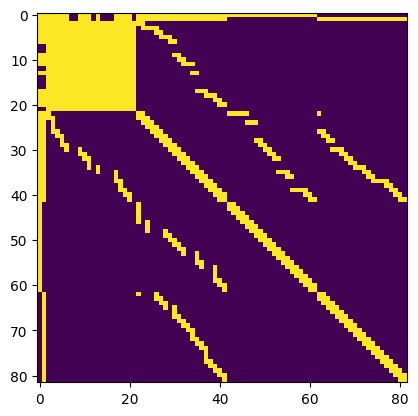

In [14]:
plt.imshow(moralize(base_mask_fn(node_id, meta_data)))

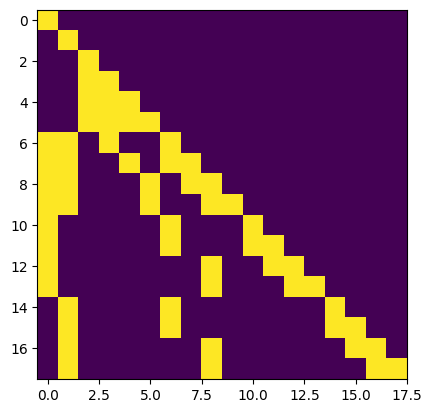

In [70]:
plt.imshow(mask_x)

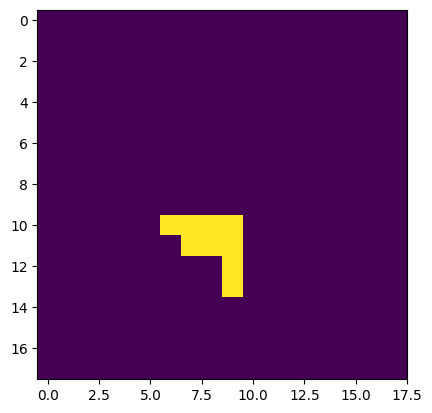

In [61]:
plt.imshow(meta_mask_I_R)

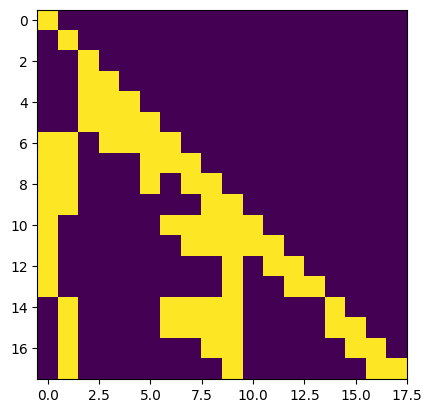

In [60]:
from probjax.utils.graph import moralize

plt.imshow(mask_x)

In [44]:
meta_data

Array([   nan,    nan,  6.961, 20.563, 22.956, 47.347, 15.438, 24.595,
       38.856, 47.835,  1.641, 16.073, 42.25 , 42.887,  6.378, 13.236,
       32.498, 39.134], dtype=float32)

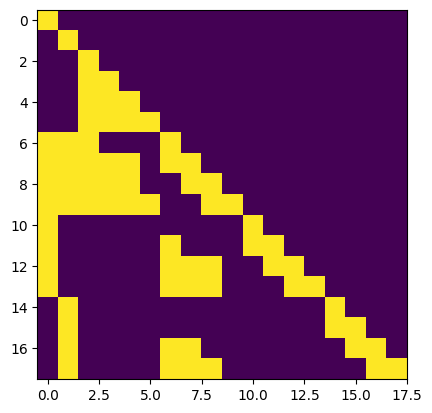

In [18]:
plt.imshow(mask_x)

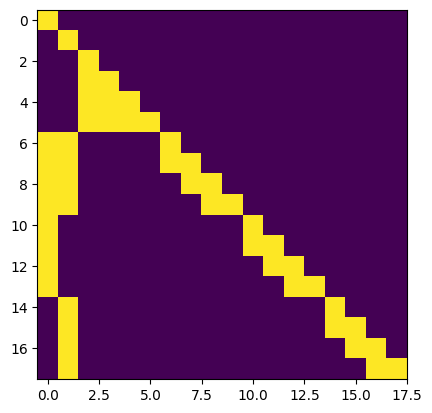

In [75]:
plt.imshow(mask_x)

In [59]:
plt.imshow(mask_x.at[index0,index1].set(jnp.where(mask_beta_I)[0])

SyntaxError: incomplete input (913933881.py, line 1)

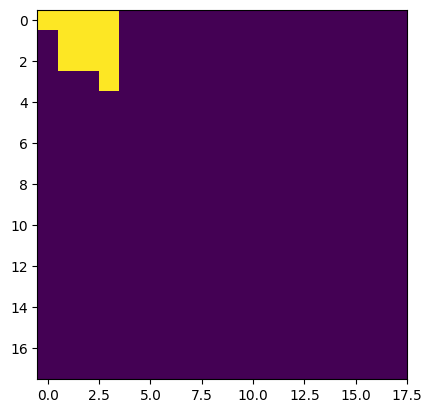

In [52]:
plt.imshow(mask_beta_I)

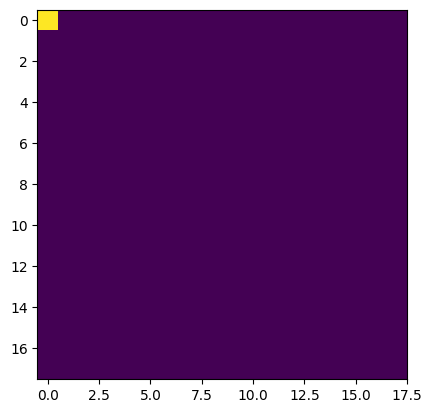

In [40]:
plt.imshow(mask_x.at[index0, index1].set(mask_beta_I[index0, index1]))


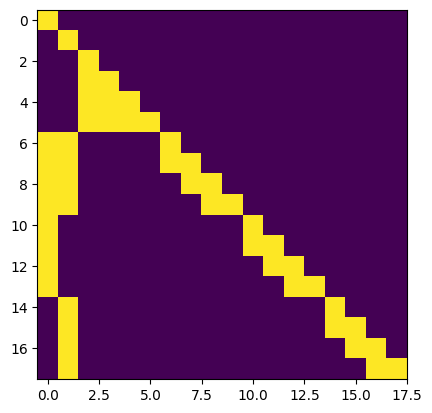

In [18]:
from probjax.utils.graph import moralize

plt.imshow(mask_x)

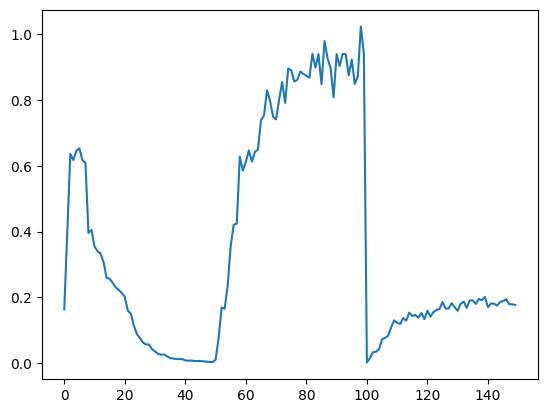

In [68]:
plt.plot(x_o)

In [69]:
with jax.default_device(jax.devices("cuda")[0]):
    samples = model.sample(200, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, meta_data=meta_data, node_id=node_id)

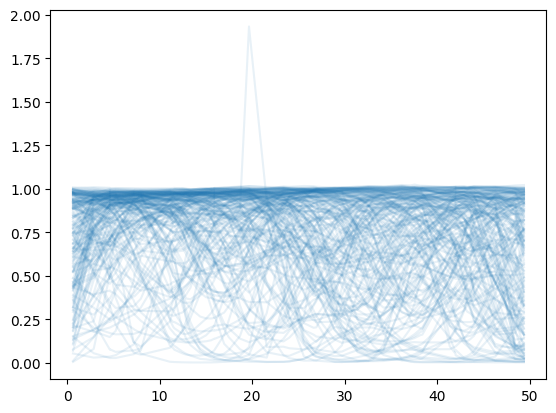

In [70]:
_ = plt.plot(meta_data[2:52], samples[:200, 2:52].T, color="C0", alpha=0.1)

In [15]:
model_ref = task.get_reference_sampler()
samples_ref = model_ref.sample(200, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, meta_data=meta_data, node_id=node_id)

dict_keys(['theta0', 'theta1', 'theta2', 'theta3']) dict_keys(['x0', 'x1'])


(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

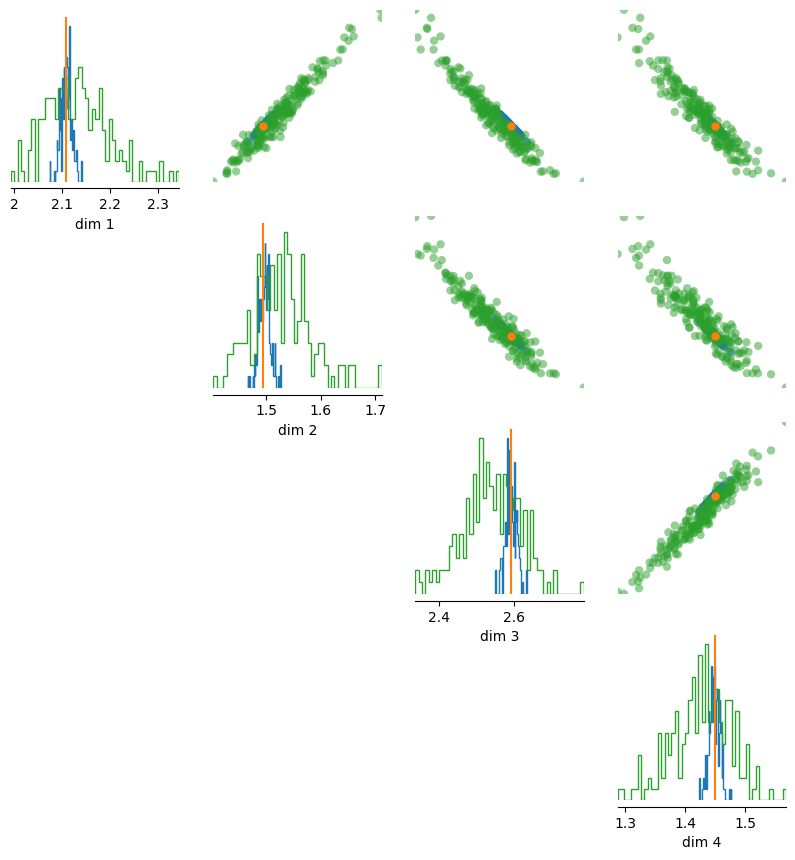

In [16]:
from sbi.analysis import pairplot
import numpy as np 

samples_ref = np.array(samples_ref)
samples = np.array(samples)
pairplot([samples_ref,samples], figsize=(10, 10), points=np.array(theta_o), upper="scatter")

In [21]:
samples = model.sample(200, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, theta_o=theta_o, meta_data=meta_data)

In [28]:
meta_data.shape

(44,)

ValueError: x and y must have same first dimension, but have shapes (20,) and (4, 200)

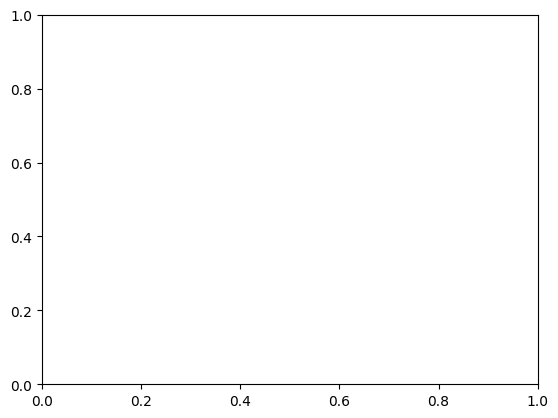

In [29]:

_ = plt.plot(meta_data[4:24],samples[:,:20].T, ".", color="C0", alpha=0.1)

In [30]:
theta_o

Array([2.244, 2.824, 2.715, 2.605], dtype=float32)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

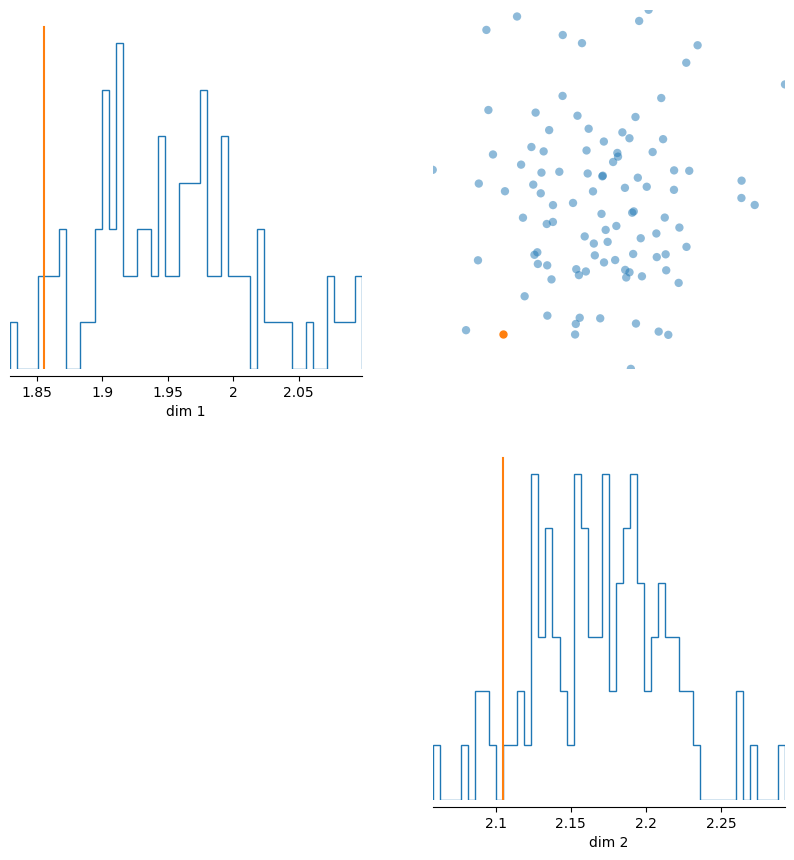

In [26]:
from sbi.analysis import pairplot
import numpy as np 

samples = np.array(samples)
pairplot(samples, figsize=(10, 10), points=np.array(theta_o), upper="scatter")

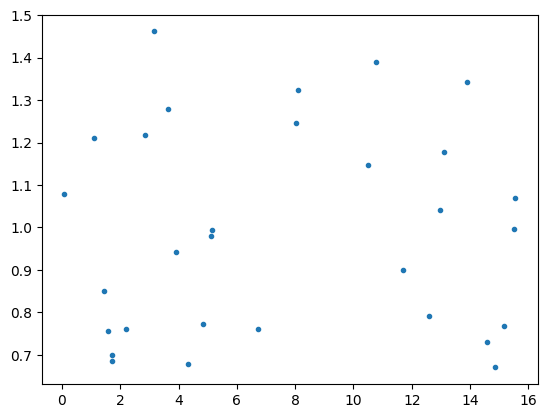

In [29]:
plt.plot(meta_data[4:34],x_o[:30], ".")